<a href="https://colab.research.google.com/github/vikashkumar97983282-glitch/machine-learning/blob/main/1_Decision_Tree_users_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

\\\\## **Building Decision Tree using sklearn**

Data set : users.csv

# **Step 1: Loading the data**




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#reading data from csv file
user=pd.read_csv('/content/drive/MyDrive/1-Subjects/1_Python_AI_ML_DL_NLP/3 Machine Learning/2. Supervised Machine Learning/2_Classification/4_Decision Tree/2_Practical/users.csv')
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          99 non-null     int64 
 1   Gender           99 non-null     object
 2   Age              99 non-null     int64 
 3   EstimatedSalary  99 non-null     int64 
 4   Purchased        99 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


In [ ]:
user.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0


In [ ]:
user['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
user['Purchased'].unique()

array([0, 1])

In [ ]:
user['Age'].max()

64

In [ ]:
user['Age'].min()

1

In [ ]:
user['EstimatedSalary'].max()

150000

In [ ]:
user['EstimatedSalary'].min()

15000

# Setting the predictors and target:

In [ ]:
#selecting predicator attributes
X=user.columns.drop("Purchased")
#selecting target attribute
y=user['Purchased']

# **Step 2: Feature engineering - Encoding**



In [ ]:
# Encoding all the predictor variables to convert the categorical values to numerical values.
user_encoded = pd.get_dummies(user[X]).astype(int)
# print("Total number of predictors after encoding = ", len(user_encoded.columns))
# # Printing the list of columns after encoding to understand the encoding process
# user_encoded.columns
# user_encoded

In [ ]:
user_encoded

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,1,0
3,15603246,27,57000,1,0
4,15804002,10,76000,0,1
...,...,...,...,...,...
94,15786993,45,83000,1,0
95,15709441,35,44000,1,0
96,15710257,4,25000,1,0
97,15582492,5,123000,0,1


# **Step 3: Splitting the dataset into train and test data**

In [ ]:
#Impotbthe required function
from sklearn.model_selection import train_test_split
#splitting data into train and test datasets
X_train,X_test,y_train,y_test = train_test_split(user_encoded, y, test_size=0.15, random_state=0)
# Printing the shape of the resulting datasets
print("Shape of X_train and y_train are:", X_train.shape, "and", y_train.shape, " respectively")
print("Shape of X_test and y_test are:", X_test.shape, "and", y_test.shape, " respectively")


Shape of X_train and y_train are: (84, 5) and (84,)  respectively
Shape of X_test and y_test are: (15, 5) and (15,)  respectively


## **Step 4: Building the model**

In [ ]:
#from scipy.sparse import random
#Importing required class
from sklearn.tree import DecisionTreeClassifier
#create object
model=DecisionTreeClassifier(criterion='gini',random_state=1)
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
# Predicting target values using the model built on training data
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

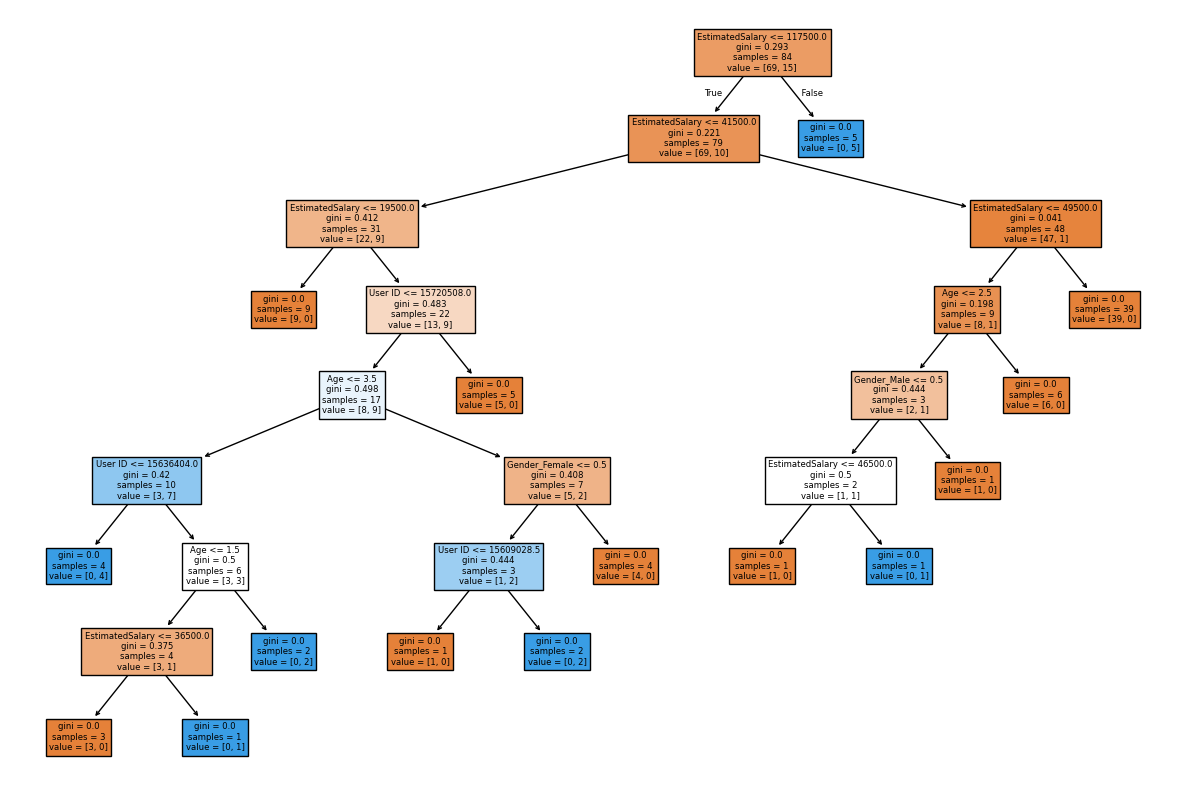

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=user_encoded.columns, filled=True)
plt.show()

# **Step 5: Evaluate model performance on train and test sets**

In [ ]:
# Getting the accuracy on train data
train_accuracy = model.score(X_train,y_train)
print("Accuracy of the model on train data = ",train_accuracy)
# Getting the accuracy on test data
test_accuracy = model.score(X_test,y_test)
print("Accuracy of the model on test data = ",test_accuracy)

Accuracy of the model on train data =  1.0
Accuracy of the model on test data =  0.8


You can observe that the training accuracy is 100% and the test accuracy is approximately 80%.

This could mean that the model is overfit to the training data and is not a good approximation of the input to output mapping.